# 5. Final Metadata DLinear

## 1. Imports and experiment settings

General settings shared by every final model so the results can be compared

In [1]:
from pathlib import Path
from types import SimpleNamespace
import itertools
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# Find the project folder when the notebook runs from notebooks/final.
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "final":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
elif PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from settings.final_config import (
    BATCH_SIZE,
    EMBEDDING_DIM,
    EVAL_GROUPS,
    FINAL_SEEDS,
    FUTURE_KNOWN_COVARIATE_COLUMNS,
    GRID,
    PAST_COVARIATE_COLUMNS,
    PRED_LEN,
    RESULT_ROOT,
    SEARCH_SEED,
    STATIC_METADATA_COLUMNS,
    SEARCH_TRAIN_END_IDX,
    TEST_END_IDX,
    TEST_START_IDX,
    VALIDATION_END_IDX,
    VALIDATION_START_IDX,
)
from settings.final_data import (
    build_forecast_data,
    build_split_ids,
    build_train_loader,
    load_existing_split,
    load_preprocessors,
    load_series_arrays,
    select_loaded_series,
)
from settings.final_evaluation import (
    create_per_series_metrics,
    create_prediction_table,
    evaluate_baselines,
    evaluate_regression_model,
    evaluate_zero_aware_model,
)
from settings.final_training import (
    train_regression_model,
    train_zero_aware_model,
)
from models.DLinearMetadata import DLinearMetadata

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

c:\Users\Francisco\Documents\Documentos-secundario\Visual-Studio-Code-Repository\CT5108_Capstone\Unified_forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cpu')

In [2]:
MODEL_NAME = "Metadata DLinear"
MODEL_SLUG = "metadata"
PAST_COLUMNS = list(PAST_COVARIATE_COLUMNS)
FUTURE_COLUMNS = []
METADATA_COLUMNS = list(STATIC_METADATA_COLUMNS)
ZERO_AWARE = False

PREPROCESSOR_DIR = RESULT_ROOT / "preprocessors"
GRID_DIR = RESULT_ROOT / "grid_results"
CHECKPOINT_DIR = RESULT_ROOT / "checkpoints"
PREDICTION_DIR = RESULT_ROOT / "predictions"
HISTORY_DIR = RESULT_ROOT / "training_history"

for folder in [GRID_DIR, CHECKPOINT_DIR, PREDICTION_DIR, HISTORY_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_NAME)
print("Past covariates:", PAST_COLUMNS)
print("Future covariates:", FUTURE_COLUMNS)
print("Metadata:", METADATA_COLUMNS)

Model: Metadata DLinear
Past covariates: ['day_of_week', 'is_weekend', 'event_flag', 'snap_flag', 'sell_price']
Future covariates: []
Metadata: ['cat_id', 'dept_id', 'state_id']


## 2. Load the fixed split and preprocessors

In [3]:
series_table = load_existing_split()
train_ids, split_ids = build_split_ids(series_table)

search_scaler, search_price_fallback, search_metadata_encoders = (
    load_preprocessors(PREPROCESSOR_DIR, prefix="search")
)
final_scaler, final_price_fallback, final_metadata_encoders = (
    load_preprocessors(PREPROCESSOR_DIR, prefix="final")
)

metadata_cardinalities = [
    max(search_metadata_encoders[column].values(), default=0) + 1
    for column in METADATA_COLUMNS
]

print("Training series:", len(train_ids))
print("Evaluation series:", len(split_ids["all_combined"]))
print("Metadata cardinalities:", metadata_cardinalities)

Training series: 24696
Evaluation series: 30490
Metadata cardinalities: [4, 8, 4]


## 3. Define the model


In [4]:
def create_model(seq_len):
    return DLinearMetadata(
        seq_len=seq_len,
        pred_len=PRED_LEN,
        n_covariates=len(PAST_COLUMNS),
        metadata_cardinalities=metadata_cardinalities,
        embedding_dim=EMBEDDING_DIM,
    )


def model_forward(model, batch):
    return model(batch["x_past"], batch["metadata"])

In [5]:
def train_one_configuration(
    loaded_data,
    seq_len,
    learning_rate,
    epochs,
    samples_per_epoch,
    seed,
    training_end,
    validation_data=None,
):
    # Create random windows from all training series.
    train_loader = build_train_loader(
        loaded_data=loaded_data,
        seq_len=seq_len,
        pred_len=PRED_LEN,
        training_end_exclusive=training_end,
        samples_per_epoch=samples_per_epoch,
        seed=seed,
        batch_size=BATCH_SIZE,
    )

    return train_regression_model(
        create_model=lambda: create_model(seq_len),
        train_loader=train_loader,
        model_forward=model_forward,
        device=device,
        learning_rate=learning_rate,
        epochs=epochs,
        seed=seed,
        validation_data=validation_data,
    )

## 4. Load search-period data

The grid trains from `d_1` to `d_1857` and selects checkpoints using validation days `d_1858` to `d_1885`.

In [6]:
search_data = load_series_arrays(
    series_ids=train_ids,
    series_table=series_table,
    required_end_idx=VALIDATION_END_IDX,
    past_covariate_columns=PAST_COLUMNS,
    future_covariate_columns=FUTURE_COLUMNS,
    metadata_columns=METADATA_COLUMNS,
    covariate_scaler=search_scaler,
    price_fallback=search_price_fallback,
    metadata_encoders=search_metadata_encoders,
)

print("Loaded search series:", len(search_data["series_ids"]))
print("Search training ends at index:", SEARCH_TRAIN_END_IDX)
print("Validation starts at index:", VALIDATION_START_IDX)

Loaded search series: 24696
Search training ends at index: 1856
Validation starts at index: 1857


## 5. Grid search

Every configuration is evaluated on the same combined validation set

In [ ]:
# grid_rows = []
# history_rows = []

# grid_combinations = list(itertools.product(
#     GRID["seq_len"],
#     GRID["learning_rate"],
#     GRID["epochs"],
#     GRID["samples_per_epoch"],
# ))

# for run_number, values in enumerate(grid_combinations, start=1):
#     seq_len, learning_rate, epochs, samples_per_epoch = values
#     run_id = f"{MODEL_SLUG}_search_{run_number:02d}"

#     print("\nGrid run:", run_id)
#     print("seq_len:", seq_len)
#     print("learning_rate:", learning_rate)
#     print("samples_per_epoch:", samples_per_epoch)

#     validation_data = build_forecast_data(
#         loaded_data=search_data,
#         seq_len=seq_len,
#         forecast_start_idx=VALIDATION_START_IDX,
#         pred_len=PRED_LEN,
#     )

#     training_result = train_one_configuration(
#         loaded_data=search_data,
#         seq_len=seq_len,
#         learning_rate=learning_rate,
#         epochs=epochs,
#         samples_per_epoch=samples_per_epoch,
#         seed=SEARCH_SEED,
#         training_end=VALIDATION_START_IDX,
#         validation_data=validation_data,
#     )

#     metrics = training_result["best_validation_metrics"]
#     checkpoint_path = CHECKPOINT_DIR / f"{run_id}.pt"

#     torch.save({
#         "run_id": run_id,
#         "model_name": MODEL_NAME,
#         "model_state_dict": {
#             name: value.detach().cpu()
#             for name, value in training_result["model"].state_dict().items()
#         },
#         "seq_len": seq_len,
#         "pred_len": PRED_LEN,
#         "learning_rate": learning_rate,
#         "samples_per_epoch": samples_per_epoch,
#         "maximum_epochs": epochs,
#         "best_epoch": training_result["best_epoch"],
#         "seed": SEARCH_SEED,
#     }, checkpoint_path)

#     grid_rows.append({
#         "run_id": run_id,
#         "model_name": MODEL_NAME,
#         "subset": "validation_train_groups",
#         "seq_len": seq_len,
#         "pred_len": PRED_LEN,
#         "learning_rate": learning_rate,
#         "batch_size": BATCH_SIZE,
#         "samples_per_epoch": samples_per_epoch,
#         "maximum_epochs": epochs,
#         "epochs_completed": len(training_result["history"]),
#         "seed": SEARCH_SEED,
#         "best_epoch": training_result["best_epoch"],
#         "first_converged_epoch": training_result["first_converged_epoch"],
#         "parameter_count": training_result["parameter_count"],
#         "number_of_series": metrics["number_of_series"],
#         "number_of_forecast_observations": metrics[
#             "number_of_forecast_observations"
#         ],
#         "mae": metrics["mae"],
#         "rmse": metrics["rmse"],
#         "wape": metrics["wape"],
#         "zero_precision": metrics["zero_precision"],
#         "zero_recall": metrics["zero_recall"],
#         "zero_f1": metrics["zero_f1"],
#         "checkpoint_path": str(checkpoint_path),
#     })

#     run_history = pd.DataFrame(training_result["history"])
#     run_history.insert(0, "run_id", run_id)
#     run_history.insert(1, "model_name", MODEL_NAME)
#     history_rows.extend(run_history.to_dict("records"))

#     # Save progress after every completed configuration.
#     pd.DataFrame(grid_rows).to_csv(
#         GRID_DIR / f"{MODEL_SLUG}_grid_validation.csv",
#         index=False,
#     )
#     pd.DataFrame(history_rows).to_csv(
#         HISTORY_DIR / f"{MODEL_SLUG}_search_training_history.csv",
#         index=False,
#     )

# grid_df = pd.DataFrame(grid_rows)
# grid_df.sort_values("wape").head(10)


Grid run: metadata_search_01
seq_len: 28
learning_rate: 0.001
samples_per_epoch: 10000


Epoch 50: 100%|██████████| 157/157 [00:00<00:00, 262.85it/s]



Grid run: metadata_search_02
seq_len: 28
learning_rate: 0.001
samples_per_epoch: 20000


Epoch 50: 100%|██████████| 313/313 [00:01<00:00, 245.12it/s]



Grid run: metadata_search_03
seq_len: 28
learning_rate: 0.001
samples_per_epoch: 40000


...


Grid run: metadata_search_17
seq_len: 112
learning_rate: 0.0003
samples_per_epoch: 20000


Epoch 50: 100%|██████████| 313/313 [00:01<00:00, 205.07it/s]



Grid run: metadata_search_18
seq_len: 112
learning_rate: 0.0003
samples_per_epoch: 40000


Epoch 50: 100%|██████████| 625/625 [00:02<00:00, 256.06it/s]


,run_id,model_name,subset,seq_len,pred_len,learning_rate,batch_size,samples_per_epoch,maximum_epochs,epochs_completed,...,parameter_count,number_of_series,number_of_forecast_observations,mae,rmse,wape,zero_precision,zero_recall,zero_f1,checkpoint_path
7,metadata_search_08,Metadata DLinear,validation_train_groups,56,28,0.0010,64,20000,50,50,...,11488,24696,691488,0.967903,2.358832,0.722137,0.757834,0.797554,0.777187,C:\Users\Francisco\Documents\Documentos-secund...
15,metadata_search_16,Metadata DLinear,validation_train_groups,112,28,0.0003,64,10000,50,50,...,22464,24696,691488,0.968203,2.351207,0.722361,0.759425,0.798423,0.778436,C:\Users\Francisco\Documents\Documentos-secund...
5,metadata_search_06,Metadata DLinear,validation_train_groups,28,28,0.0003,64,40000,50,50,...,6000,24696,691488,0.972837,2.309012,0.725818,0.774451,0.761460,0.767901,C:\Users\Francisco\Documents\Documentos-secund...
13,metadata_search_14,Metadata DLinear,validation_train_groups,112,28,0.0010,64,20000,50,50,...,22464,24696,691488,0.973012,2.347830,0.725949,0.759104,0.786606,0.772610,C:\Users\Francisco\Documents\Documentos-secund...
11,metadata_search_12,Metadata DLinear,validation_train_groups,56,28,0.0003,64,40000,50,50,...,11488,24696,691488,0.975004,2.299716,0.727435,0.775404,0.752597,0.763830,C:\Users\Francisco\Documents\Documentos-secund...
10,metadata_search_11,Metadata DLinear,validation_train_groups,56,28,0.0003,64,20000,50,50,...,11488,24696,691488,0.975065,2.321698,0.727481,0.772947,0.762388,0.767631,C:\Users\Francisco\Documents\Documentos-secund...
2,metadata_search_03,Metadata DLinear,validation_train_groups,28,28,0.0010,64,40000,50,50,...,6000,24696,691488,0.975162,2.304913,0.727553,0.773415,0.760599,0.766953,C:\Users\Francisco\Documents\Documentos-secund...
16,metadata_search_17,Metadata DLinear,validation_train_groups,112,28,0.0003,64,20000,50,50,...,22464,24696,691488,0.975323,2.364640,0.727673,0.760995,0.790124,0.775286,C:\Users\Francisco\Documents\Documentos-secund...
6,metadata_search_07,Metadata DLinear,validation_train_groups,56,28,0.0010,64,10000,50,50,...,11488,24696,691488,0.975374,2.344781,0.727711,0.763426,0.777723,0.770508,C:\Users\Francisco\Documents\Documentos-secund...
9,metadata_search_10,Metadata DLinear,validation_train_groups,56,28,0.0003,64,10000,50,50,...,11488,24696,691488,0.976594,2.315282,0.728621,0.775386,0.754062,0.764575,C:\Users\Francisco\Documents\Documentos-secund...


## 6. Select one configuration

Minimum aggregate validation WAPE

In [ ]:
# selected_row = (
#     grid_df
#     .sort_values(["wape", "rmse", "parameter_count"])
#     .iloc[0]
# )

# selected_config = {
#     "model_name": MODEL_NAME,
#     "selected_run_id": selected_row["run_id"],
#     "selection_rule": "minimum aggregate validation WAPE",
#     "seq_len": int(selected_row["seq_len"]),
#     "pred_len": PRED_LEN,
#     "learning_rate": float(selected_row["learning_rate"]),
#     "samples_per_epoch": int(selected_row["samples_per_epoch"]),
#     "maximum_epochs": int(selected_row["maximum_epochs"]),
#     "selected_epochs": int(selected_row["best_epoch"]),
#     "search_seed": SEARCH_SEED,
#     "validation_wape": float(selected_row["wape"]),
#     "validation_rmse": float(selected_row["rmse"]),
# }

# with open(
#     GRID_DIR / f"{MODEL_SLUG}_selected_config.json",
#     "w",
#     encoding="utf-8",
# ) as file:
#     json.dump(selected_config, file, indent=2)

# selected_config

{'model_name': 'Metadata DLinear',
 'selected_run_id': 'metadata_search_08',
 'selection_rule': 'minimum aggregate validation WAPE',
 'seq_len': 56,
 'pred_len': 28,
 'learning_rate': 0.001,
 'samples_per_epoch': 20000,
 'maximum_epochs': 50,
 'selected_epochs': 46,
 'search_seed': 42,
 'validation_wape': 0.7221367955207825,
 'validation_rmse': 2.3588321208953857}

In [7]:
# Load the configuration already selected using validation data.

selected_config_path = (
    GRID_DIR / f"{MODEL_SLUG}_selected_config.json"
)

with open(
    selected_config_path,
    encoding="utf-8",
) as file:
    selected_config = json.load(file)

selected_config

{'model_name': 'Metadata DLinear',
 'selected_run_id': 'metadata_search_08',
 'selection_rule': 'minimum aggregate validation WAPE',
 'seq_len': 56,
 'pred_len': 28,
 'learning_rate': 0.001,
 'samples_per_epoch': 20000,
 'maximum_epochs': 50,
 'selected_epochs': 46,
 'search_seed': 42,
 'validation_wape': 0.7221367955207825,
 'validation_rmse': 2.3588321208953857}

## 7. Load final training and test data

The selected configuration is refitted using train + validation info `d_1` to `d_1885`. The final test is `d_1886` to `d_1913`

In [8]:
metadata_cardinalities = [
    max(final_metadata_encoders[column].values(), default=0) + 1
    for column in METADATA_COLUMNS
]

all_final_data = load_series_arrays(
    series_ids=split_ids["all_combined"],
    series_table=series_table,
    required_end_idx=TEST_END_IDX,
    past_covariate_columns=PAST_COLUMNS,
    future_covariate_columns=FUTURE_COLUMNS,
    metadata_columns=METADATA_COLUMNS,
    covariate_scaler=final_scaler,
    price_fallback=final_price_fallback,
    metadata_encoders=final_metadata_encoders,
)

final_train_data = select_loaded_series(all_final_data, train_ids)
test_data_by_subset = {}

for subset_name in EVAL_GROUPS:
    subset_data = select_loaded_series(
        all_final_data,
        split_ids[subset_name],
    )
    test_data_by_subset[subset_name] = build_forecast_data(
        loaded_data=subset_data,
        seq_len=selected_config["seq_len"],
        forecast_start_idx=TEST_START_IDX,
        pred_len=PRED_LEN,
    )

print("Final training series:", len(final_train_data["series_ids"]))
print("Final test series:", len(all_final_data["series_ids"]))

Final training series: 24696
Final test series: 30490


## 8. Refit and evaluate the selected model

Train independently with each seed the final configuration

In [9]:
final_metric_rows = []
final_history_rows = []

for seed in FINAL_SEEDS:
    run_id = f"{MODEL_SLUG}_final_seed_{seed}"
    print("\nFinal run:", run_id)

    training_result = train_one_configuration(
        loaded_data=final_train_data,
        seq_len=selected_config["seq_len"],
        learning_rate=selected_config["learning_rate"],
        epochs=selected_config["selected_epochs"],
        samples_per_epoch=selected_config["samples_per_epoch"],
        seed=seed,
        training_end=TEST_START_IDX,
        validation_data=None,
    )

    model = training_result["model"]
    checkpoint_path = CHECKPOINT_DIR / f"{run_id}.pt"

    torch.save({
        "run_id": run_id,
        "model_name": MODEL_NAME,
        "model_state_dict": {
            name: value.detach().cpu()
            for name, value in model.state_dict().items()
        },
        "selected_config": selected_config,
        "seed": seed,
        "training_end_idx": TEST_START_IDX - 1,
        "test_start_idx": TEST_START_IDX,
        "test_end_idx": TEST_END_IDX,
    }, checkpoint_path)

    prediction_tables = []
    per_series_tables = []

    for subset_name, test_data in test_data_by_subset.items():
        metrics, prediction = evaluate_regression_model(
            model,
            test_data,
            model_forward,
            device,
        )

        final_metric_rows.append({
            "run_id": run_id,
            "model_name": MODEL_NAME,
            "subset": subset_name,
            "seq_len": selected_config["seq_len"],
            "pred_len": PRED_LEN,
            "learning_rate": selected_config["learning_rate"],
            "batch_size": BATCH_SIZE,
            "samples_per_epoch": selected_config["samples_per_epoch"],
            "epochs_completed": selected_config["selected_epochs"],
            "seed": seed,
            "parameter_count": training_result["parameter_count"],
            **metrics,
        })

        # all_combined repeats the four exclusive groups, so only
        # save detailed rows for the exclusive subsets.
        if subset_name != "all_combined":
            prediction_tables.append(create_prediction_table(
                run_id=run_id,
                model_name=MODEL_NAME,
                seed=seed,
                subset_name=subset_name,
                forecast_data=test_data,
                prediction=prediction,
                series_table=series_table,
            ))
            per_series_tables.append(create_per_series_metrics(
                run_id=run_id,
                model_name=MODEL_NAME,
                seed=seed,
                subset_name=subset_name,
                forecast_data=test_data,
                prediction=prediction,
                series_table=series_table,
            ))

    pd.concat(prediction_tables, ignore_index=True).to_parquet(
        PREDICTION_DIR / f"{run_id}_test_predictions.parquet",
        index=False,
    )
    pd.concat(per_series_tables, ignore_index=True).to_parquet(
        PREDICTION_DIR / f"{run_id}_per_series_metrics.parquet",
        index=False,
    )

    run_history = pd.DataFrame(training_result["history"])
    run_history.insert(0, "run_id", run_id)
    run_history.insert(1, "model_name", MODEL_NAME)
    final_history_rows.extend(run_history.to_dict("records"))

    # Save progress after every seed.
    pd.DataFrame(final_metric_rows).to_csv(
        GRID_DIR / f"{MODEL_SLUG}_final_metrics.csv",
        index=False,
    )
    pd.DataFrame(final_history_rows).to_csv(
        HISTORY_DIR / f"{MODEL_SLUG}_final_training_history.csv",
        index=False,
    )

final_metrics_df = pd.DataFrame(final_metric_rows)
final_metrics_df


Final run: metadata_final_seed_42


Epoch 46: 100%|██████████| 313/313 [00:02<00:00, 145.47it/s]



Final run: metadata_final_seed_300


Epoch 46: 100%|██████████| 313/313 [00:05<00:00, 55.68it/s]



Final run: metadata_final_seed_2026


...


Final run: metadata_final_seed_7


Epoch 46: 100%|██████████| 313/313 [00:03<00:00, 87.43it/s]



Final run: metadata_final_seed_1234


Epoch 46: 100%|██████████| 313/313 [00:02<00:00, 147.95it/s]


,run_id,model_name,subset,seq_len,pred_len,learning_rate,batch_size,samples_per_epoch,epochs_completed,seed,...,balanced_accuracy,true_zero_predicted_zero,true_zero_predicted_nonzero,true_nonzero_predicted_zero,true_nonzero_predicted_nonzero,number_of_series,number_of_forecast_observations,zero_ratio,total_actual_demand,total_predicted_demand
0,metadata_final_seed_42,Metadata DLinear,normal,56,28,0.001,64,20000,46,42,...,0.621553,22432,44564,13373,132431,7600,212800,0.314831,635631.0,458137.437500
1,metadata_final_seed_42,Metadata DLinear,intermittent,56,28,0.001,64,20000,46,42,...,0.664454,273142,52312,78204,75030,17096,478688,0.679888,300201.0,212319.078125
2,metadata_final_seed_42,Metadata DLinear,cold_start_item,56,28,0.001,64,20000,46,42,...,0.716525,33681,13226,10970,27523,3050,85400,0.549262,134412.0,101425.281250
3,metadata_final_seed_42,Metadata DLinear,cold_start_store,56,28,0.001,64,20000,46,42,...,0.721294,28504,12599,8964,26765,2744,76832,0.534972,113382.0,82841.921875
4,metadata_final_seed_42,Metadata DLinear,all_combined,56,28,0.001,64,20000,46,42,...,0.722934,357759,122701,111511,261749,30490,853720,0.562784,1183626.0,854723.750000
5,metadata_final_seed_300,Metadata DLinear,normal,56,28,0.001,64,20000,46,300,...,0.607371,19388,47608,10884,134920,7600,212800,0.314831,635631.0,502542.812500
6,metadata_final_seed_300,Metadata DLinear,intermittent,56,28,0.001,64,20000,46,300,...,0.666226,260184,65270,71560,81674,17096,478688,0.679888,300201.0,240005.937500
7,metadata_final_seed_300,Metadata DLinear,cold_start_item,56,28,0.001,64,20000,46,300,...,0.711484,31792,15115,9808,28685,3050,85400,0.549262,134412.0,111872.812500
8,metadata_final_seed_300,Metadata DLinear,cold_start_store,56,28,0.001,64,20000,46,300,...,0.712400,26497,14606,7855,27874,2744,76832,0.534972,113382.0,91220.414062
9,metadata_final_seed_300,Metadata DLinear,all_combined,56,28,0.001,64,20000,46,300,...,0.717503,337861,142599,100107,273153,30490,853720,0.562784,1183626.0,945642.000000


## 9. Summarize the final results

Means and standard deviations show performance and seed variability

In [10]:
final_summary = (
    final_metrics_df
    .groupby(["model_name", "subset"])
    .agg(
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        wape_mean=("wape", "mean"),
        wape_std=("wape", "std"),
        zero_f1_mean=("zero_f1", "mean"),
        zero_f1_std=("zero_f1", "std"),
    )
    .reset_index()
)

final_summary

,model_name,subset,mae_mean,mae_std,rmse_mean,rmse_std,wape_mean,wape_std,zero_f1_mean,zero_f1_std
0,Metadata DLinear,all_combined,1.017626,0.012193,2.358838,0.057727,0.733988,0.008795,0.749012,0.007756
1,Metadata DLinear,cold_start_item,1.143069,0.013522,2.768026,0.118313,0.726260,0.008592,0.731137,0.007493
2,Metadata DLinear,cold_start_store,1.075431,0.012206,2.346425,0.040595,0.728753,0.008271,0.721701,0.011551
3,Metadata DLinear,intermittent,0.611613,0.010225,1.208748,0.010359,0.975253,0.016304,0.803247,0.006682
4,Metadata DLinear,normal,1.859727,0.026148,3.737793,0.096346,0.622610,0.008754,0.427052,0.016766


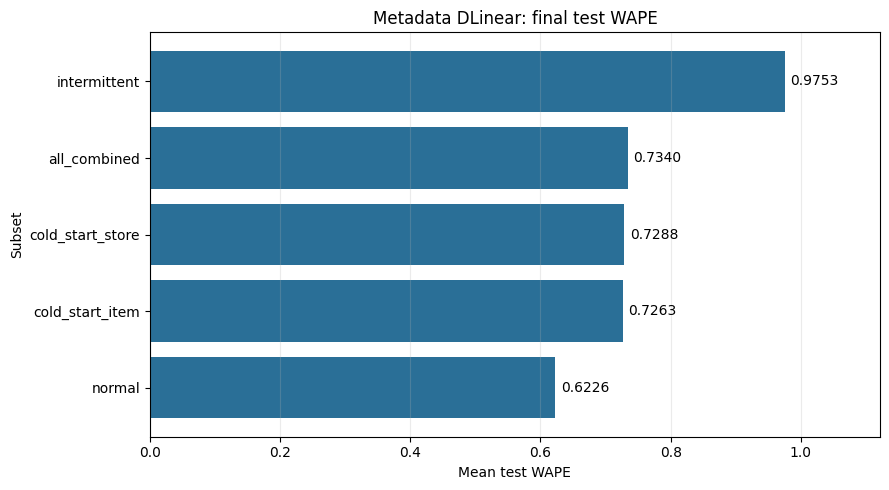

In [11]:
plot_data = final_summary.sort_values("wape_mean")

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    plot_data["subset"],
    plot_data["wape_mean"],
    color="#2A6F97",
)

# Add the WAPE value next to each bar.
ax.bar_label(
    bars,
    fmt="%.4f",
    padding=4,
)

# Add space so the labels are not cut off.
ax.set_xlim(0, plot_data["wape_mean"].max() * 1.15)

ax.set_xlabel("Mean test WAPE")
ax.set_ylabel("Subset")
ax.set_title(f"{MODEL_NAME}: final test WAPE")
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

In [12]:
final_metrics_df.groupby("subset")["seed"].nunique()

subset
all_combined        5
cold_start_item     5
cold_start_store    5
intermittent        5
normal              5
Name: seed, dtype: int64

## Final notes
